### Imports

In [ ]:
import numpy as np
import scipy  
import astropy
import matplotlib.pyplot as plt
from astropy.io import fits
import glob

### Let's also generate some fake data.

In [ ]:
import importlib
import fake_data as fd
importlib.reload(fd)

fd.generate_all("/Users/Djslime07/ASTRO-4410-FA26-mts246/Lab 1 - CCD Characterization/fake_data")

### A. Measuring the Bias and Read Noise

Bias level (mean of means): 592.3481310388712
Read noise (mean of stds): 23.610979895006835
Std of means (frame-to-frame bias stability): 0.34497841969507836
Std of stds (frame-to-frame noise consistency): 0.03628486813161773


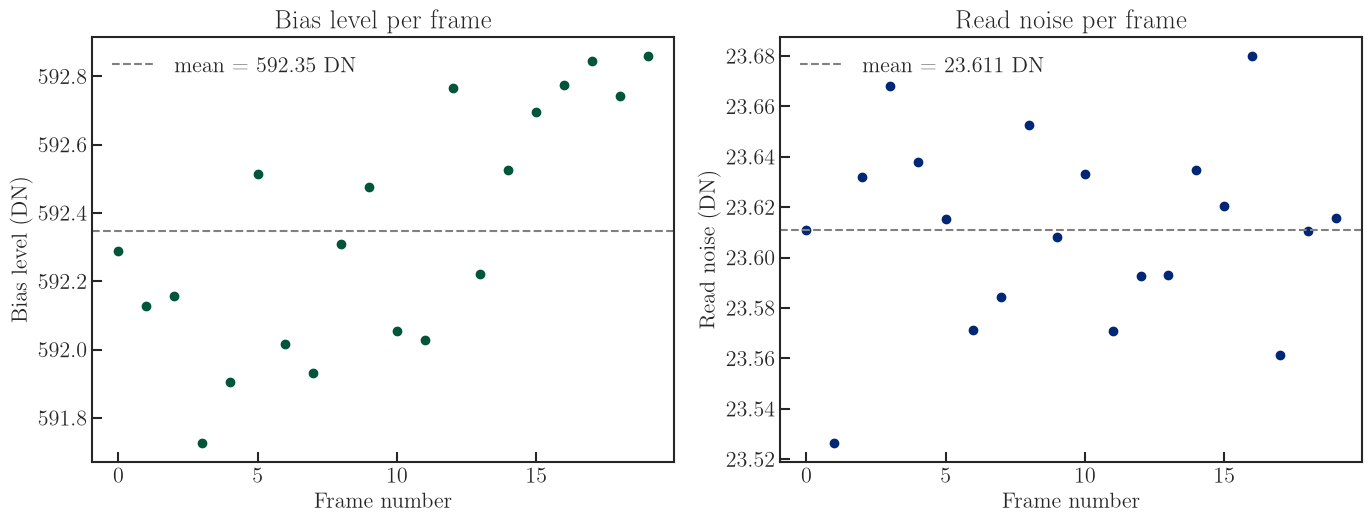

In [152]:
import importlib
import bias_and_read_noise as brn
importlib.reload(brn)

brn.compute_bias_and_read_noise("/Users/Djslime07/ASTRO-4410-FA26-mts246/Lab 1 - CCD Characterization/real_data/section_A")

### B. Linearity and Saturation

Loaded 8 frames, exposure times (s): [0.001 0.002 0.003 0.004 0.005 0.006 0.007 0.008]
Centroid: (337.59, 277.76)
Linear fit (using 3 points): signal = 57751500.00 * exptime + -18887.83
Residuals (%) for fitted points:
      0.0020s : -0.77%
      0.0030s : +0.96%
      0.0040s : -0.35%

 exptime (s)    peak (DN)    aperture sum (DN)         flag
       0.001       7493.0              41192.0    short-exp
       0.002      16124.0              95876.0             
       0.003      25774.0             155845.0             
       0.004      38725.0             211379.0             
       0.005      48809.0             266143.0     near-sat
       0.006      59104.0             334034.0     near-sat
       0.007      62626.0             382136.0     near-sat
       0.008      65535.0             430001.0    SATURATED
Loaded 12 frames, exposure times (s): [0.001 0.002 0.003 0.004 0.005 0.006 0.007 0.008 0.009 0.01  0.011 0.012]
Centroid: (337.59, 277.77)
Linear fit (using 7 points): sig

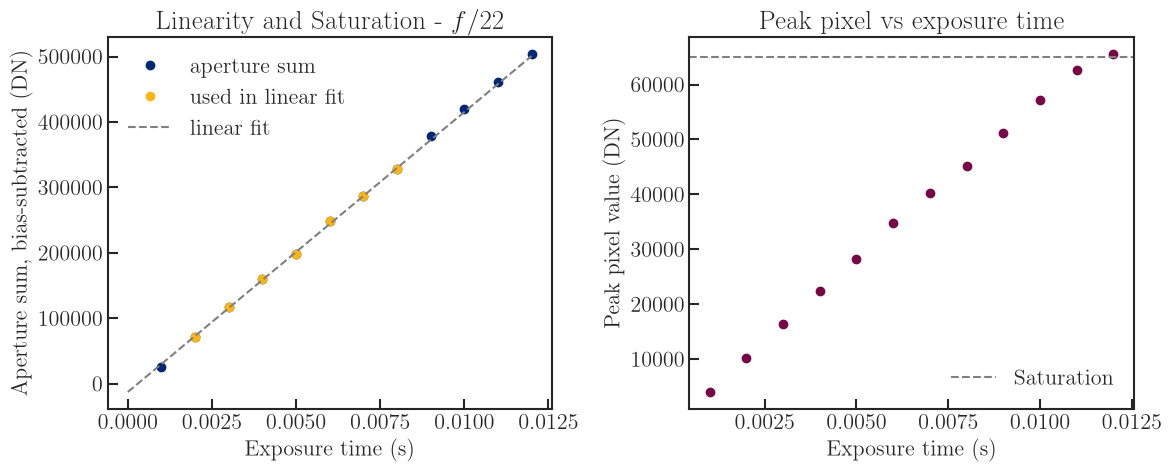

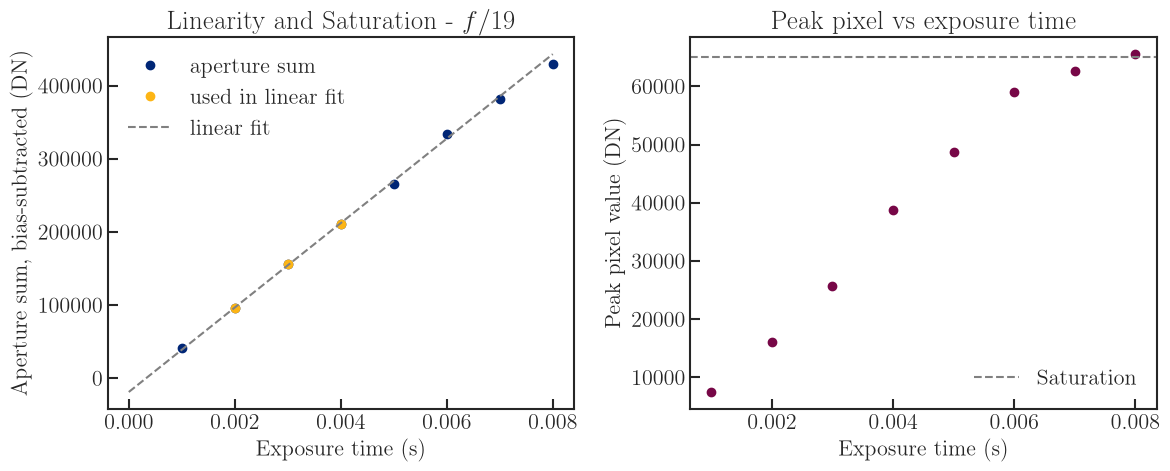

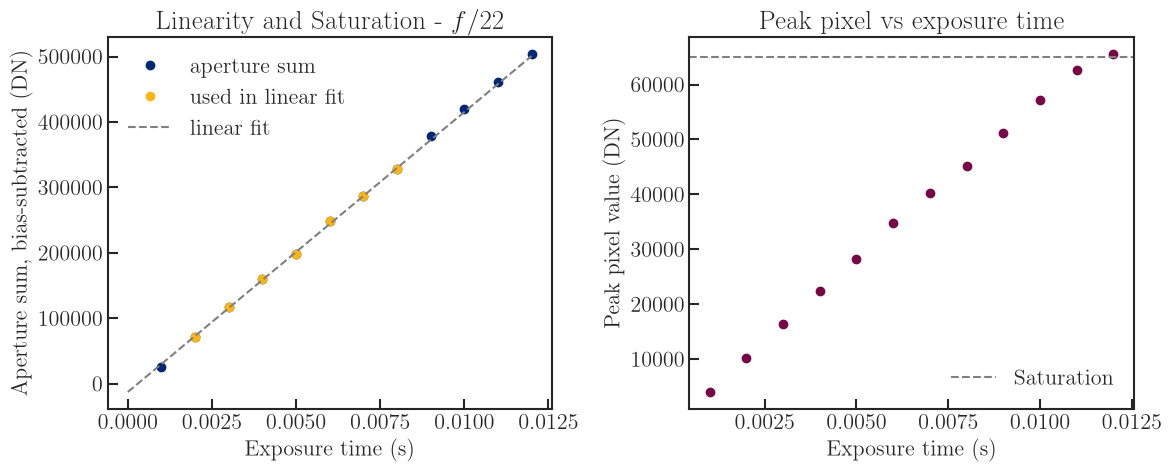

In [153]:
import importlib
import linearity_and_saturation as ls
importlib.reload(ls)

f19_results = ls.analyze_linearity(
    "/Users/Djslime07/ASTRO-4410-FA26-mts246/Lab 1 - CCD Characterization/real_data/section_B/f19",
    short_exptime_cutoff_s=0.0015  # excludes only the 0.001s point
)
ls.plot_linearity(f19_results, 
                  save_path="/Users/Djslime07/ASTRO-4410-FA26-mts246/Lab 1 - CCD Characterization/plots/linearity_and_saturation_f19.png", 
                  save_path2="/Users/Djslime07/ASTRO-4410-FA26-mts246/Lab 1 - CCD Characterization/nicer_plots/linearity_and_saturation_f19.pdf",
                  title=r"Linearity and Saturation - $f/19$")

f22_results = ls.analyze_linearity(
    "/Users/Djslime07/ASTRO-4410-FA26-mts246/Lab 1 - CCD Characterization/real_data/section_B/f22",           
    short_exptime_cutoff_s=0.0015  # excludes only the 0.001s point
)
ls.plot_linearity(f22_results, 
                  save_path="/Users/Djslime07/ASTRO-4410-FA26-mts246/Lab 1 - CCD Characterization/plots/linearity_and_saturation_f22.png", 
                  save_path2="/Users/Djslime07/ASTRO-4410-FA26-mts246/Lab 1 - CCD Characterization/nicer_plots/linearity_and_saturation_f22.pdf",
                  title=r"Linearity and Saturation - $f/22$")

### C. Dark Current

Loaded 12 frames, exposure times (s): [  1.   1.   1.   5.   5.   5.  20.  20.  20.  60. 120. 300.]

Single pixel (329, 246): slope = 0.0228 DN/s, intercept = 701.2 DN
Region median: slope = 0.0387 DN/s, intercept = 705.8 DN
Loaded 12 frames, exposure times (s): [  1.   1.   1.   5.   5.   5.  20.  20.  20.  60. 120. 300.]

Single pixel (329, 246): slope = 0.0958 DN/s, intercept = 614.0 DN
Region median: slope = 0.1432 DN/s, intercept = 611.8 DN


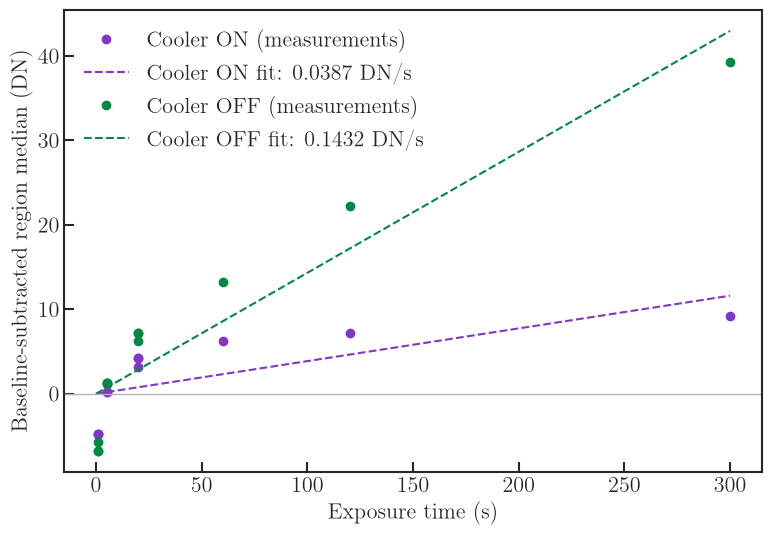

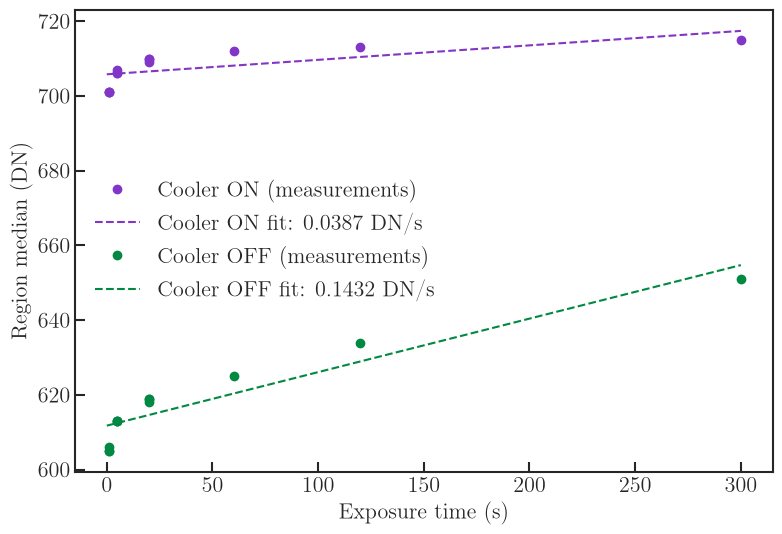

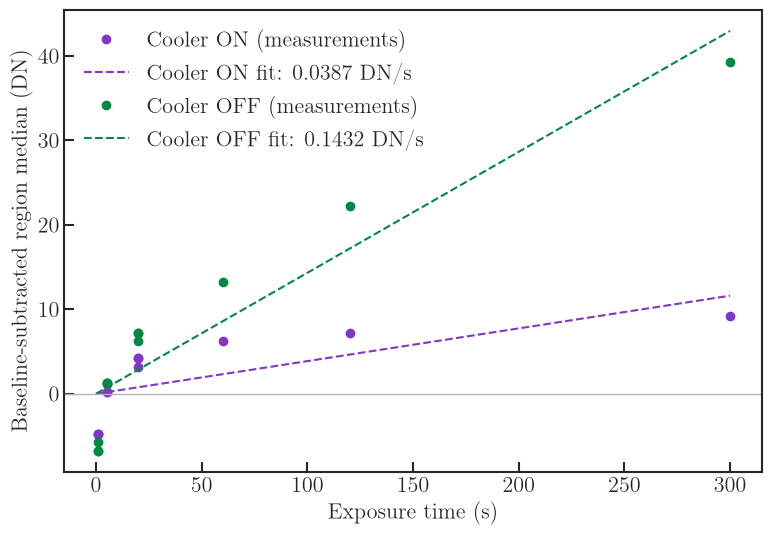

In [155]:
import importlib
import dark_current as dc
importlib.reload(dc)

on_results = dc.analyze_dark_current("/Users/Djslime07/ASTRO-4410-FA26-mts246/Lab 1 - CCD Characterization/real_data/section_C/Cooler Active")
off_results = dc.analyze_dark_current("/Users/Djslime07/ASTRO-4410-FA26-mts246/Lab 1 - CCD Characterization/real_data/section_C/Cooler Inactive")

dc.plot_comparison(off_results, on_results)
dc.plot_comparison_baseline(off_results, on_results)

### D. DN-to-electrons

Loaded 11 frames, exposure times (s): [1.e-01 2.e-01 5.e-01 1.e+00 2.e+00 5.e+00 1.e+01 2.e+01 5.e+01 1.e+02
 2.e+02]

 exptime (s)    signal (DN)   noise (DN)  shot noise (DN)           regime
       0.100          161.2        27.87            14.81                 
       0.200          258.1        33.29            23.47                 
       0.500          426.6        40.77            33.24       shot noise
       1.000          684.2        49.85            43.90       shot noise
       2.000         1195.1        64.64            60.18       shot noise
       5.000         2726.9        96.68            93.76       shot noise
      10.000         5241.2       134.31           132.22       shot noise
      20.000        10422.8       190.88           189.41       shot noise
      50.000        25292.8       309.58           308.68       shot noise
     100.000        49611.7       454.73           454.12                 
     200.000        64196.9      1110.75          1110.5

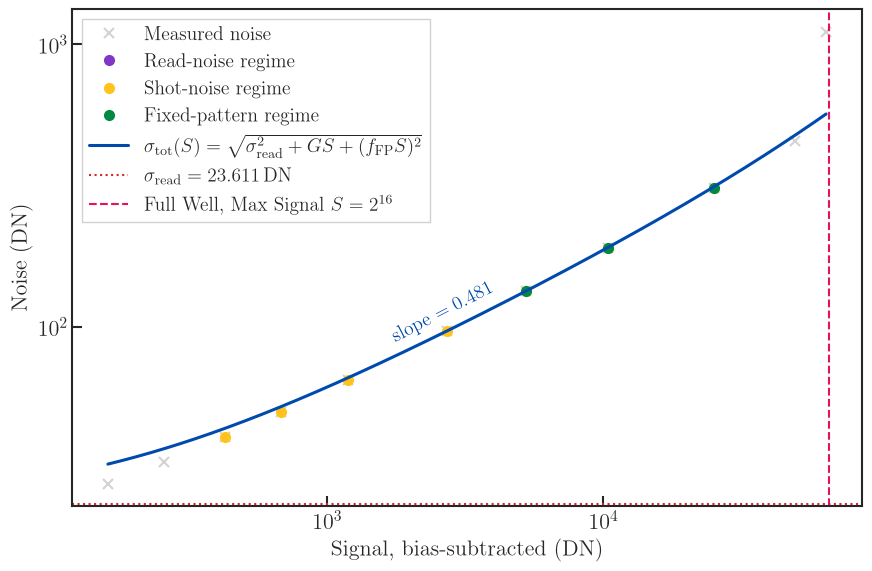

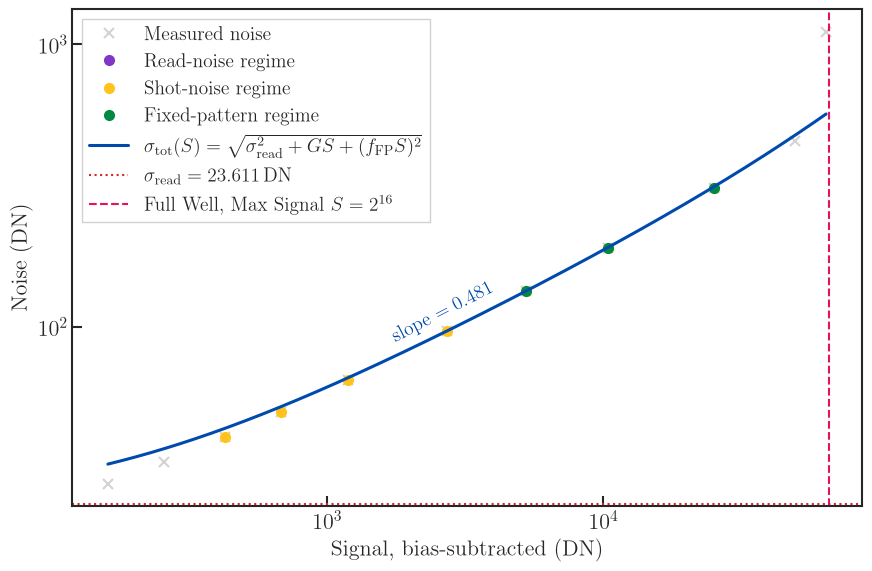

In [151]:
import importlib
import photon_transfer as pt
importlib.reload(pt)

results = pt.analyze_photon_transfer(
    "/Users/Djslime07/ASTRO-4410-FA26-mts246/Lab 1 - CCD Characterization/real_data/section_D",
    bias_level=592.3481310388712,          # from Section A 
    read_noise_dn=23.610979895006835,      # from Section A 
)
pt.plot_ptc(results)

### E. Cosmic Rays

In [132]:
import importlib
import cosmic_rays as cs
importlib.reload(cs)

andor_results, atik_results = cs.full_analyze(
    andor_dir="/Users/Djslime07/ASTRO-4410-FA26-mts246/Lab 1 - CCD Characterization/AndorCCD-CosmicRays",
    atik_dir="/Users/Djslime07/ASTRO-4410-FA26-mts246/Lab 1 - CCD Characterization/CRtest",
    output_dir="/Users/Djslime07/ASTRO-4410-FA26-mts246/Lab 1 - CCD Characterization/plots",
)

cs.make_publication_figures(andor_results, atik_results, 
                            "/Users/Djslime07/ASTRO-4410-FA26-mts246/Lab 1 - CCD Characterization/cosmic_figs",
)

CCD profile: andor  (pixel pitch = 13.5 um, exptime = 600.0 s)

Loaded 19 frames from /Users/Djslime07/ASTRO-4410-FA26-mts246/Lab 1 - CCD Characterization/AndorCCD-CosmicRays/, shape (19, 512, 2048)
Median map level: 159.0 DN, robust sigma: 1.48 DN, threshold: 166.4 DN
Hot pixels found: 107
Residual robust sigma: 5.93 DN, cosmic-ray threshold: 29.7 DN
Cosmic ray candidates per frame: [    102      89 1048469      96      73     146      83     110      82
     116     155     105      92     147      83      68      76     205
      98]

*** 1 BAD FRAME(S) DETECTED (>1.0% of pixels flagged -- not real cosmic ray statistics, likely light leak / saturation / corruption): ***
    frame index 2: 1048469 pixels (100.0% of frame) -- excluded from rate
    -> Inspect these frames directly (e.g. plt.imshow) before trusting the rate below.

Good frames used for rate: 18 / 19
Mean events/frame (good frames only): 107.00
Bad frame file paths:
    [2] /Users/Djslime07/ASTRO-4410-FA26-mts246/Lab 1 

### For the ``Exercise 1`` in class: Installing ``astropy``.

Filename: /Users/Djslime07/ASTRO-4410-FA26-mts246/Lab 1 - CCD Characterization/real_data/section_B/f22/CCD Image 52.fit
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU      32   (658, 492)   int16 (rescales to uint16)   


Text(0.5, 1.0, 'Atik Titan CCD Frame 52, $f/22$, 0.012s exposure')

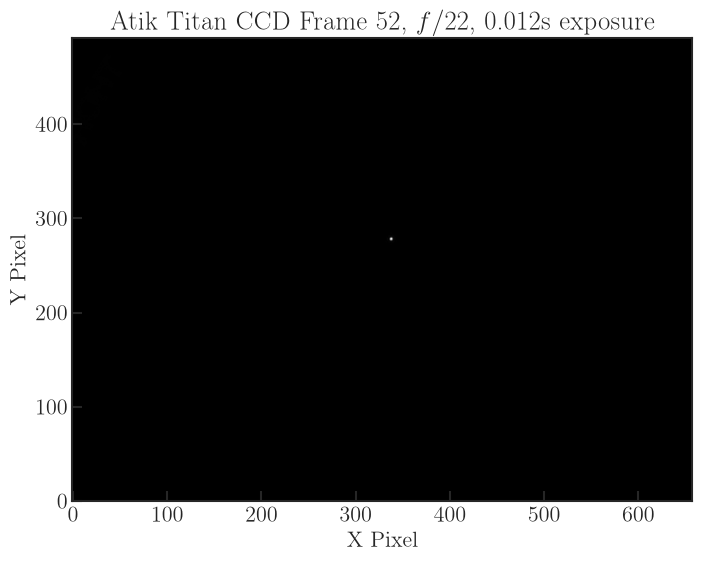

In [94]:
import matplotlib.pyplot as plt
from astropy.io import fits
import numpy as np

data = "/Users/Djslime07/ASTRO-4410-FA26-mts246/Lab 1 - CCD Characterization/real_data/section_B/f22/CCD Image 52.fit"
hdu_list = fits.open(data)
hdu_list.info()

plt.figure(figsize = (8, 8))
plt.imshow(fits.getdata(data), cmap="gray", origin="lower")
plt.xlabel("X Pixel")
plt.ylabel("Y Pixel")
plt.title(r"Atik Titan CCD Frame 52, $f/22$, 0.012s exposure")